In [1]:
import os
import sys
import glob
import json
import h5py
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.voltage.summary import VoltageSummary
from vip_slap2_analysis.utils.utils import save_figure
from vip_slap2_analysis.voltage.extraction import  load_voltage_roi_transform_h5

display(HTML("<style>.container { width:100% !important; }</style>"))
warnings.filterwarnings("default")

import seaborn as sns
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [2]:
%load_ext autoreload
%autoreload 2

%matplotlib notebook

In [12]:
session_path = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP8\875436\875436_2026-07-20_11-20-21"
datapath = glob.glob(os.path.join(session_path,'**','dendriticVoltageSummary**.mat'),recursive=True)[0]
savepath = r"C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures"

In [13]:
vs = VoltageSummary(datapath)

In [14]:
meanIM_dmd1 = vs.get_mean_image(dmd=1)
meanIM_dmd2 = vs.get_mean_image(dmd=2)

In [15]:
meanIM_dmd1.shape

(1280, 2, 800)

<IPython.core.display.Javascript object>


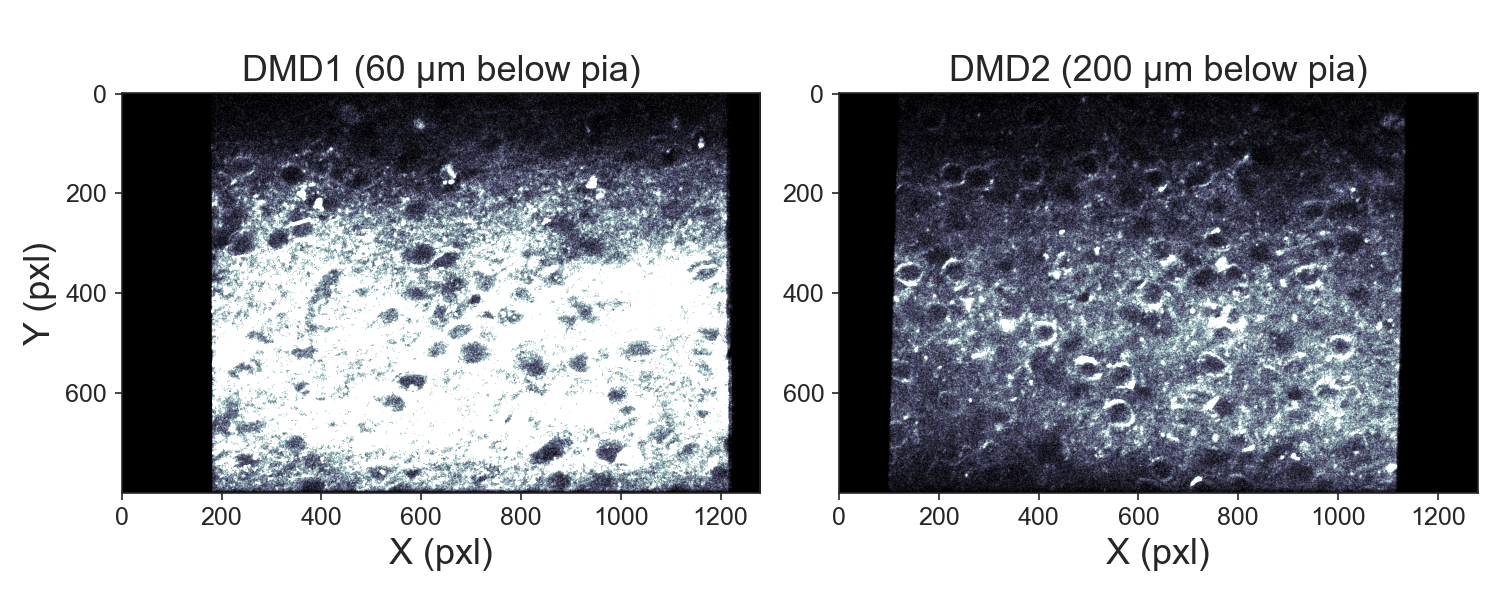

In [16]:
fig,ax=plt.subplots(1,2,figsize=(10,4),sharex=True,sharey=True)

for axis in ax.flatten():
    axis.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
    axis.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)
    axis.set_xlabel('X (pxl)')
    
ax[0].set_title('DMD1 (60 \u03BCm below pia)')
ax[1].set_title('DMD2 (200 \u03BCm below pia)')
ax[0].set_ylabel('Y (pxl)')

ax[0].imshow(meanIM_dmd1[:,0,:][::].T,cmap='bone',vmax=40,vmin=0)
ax[1].imshow(meanIM_dmd2[:,0,:][::].T,cmap='bone',vmax=40,vmin=0)

fig.tight_layout()
filen = '2026-06-23_ASAP8_ref_meanIM'
# save_figure(fig,os.path.join(savepath,filen),formats=['.pdf'],dpi=300)

In [17]:
dmd1_traces = vs.get_roi_traces(dmd=1).T
dmd2_traces = vs.get_roi_traces(dmd=2).T

<IPython.core.display.Javascript object>


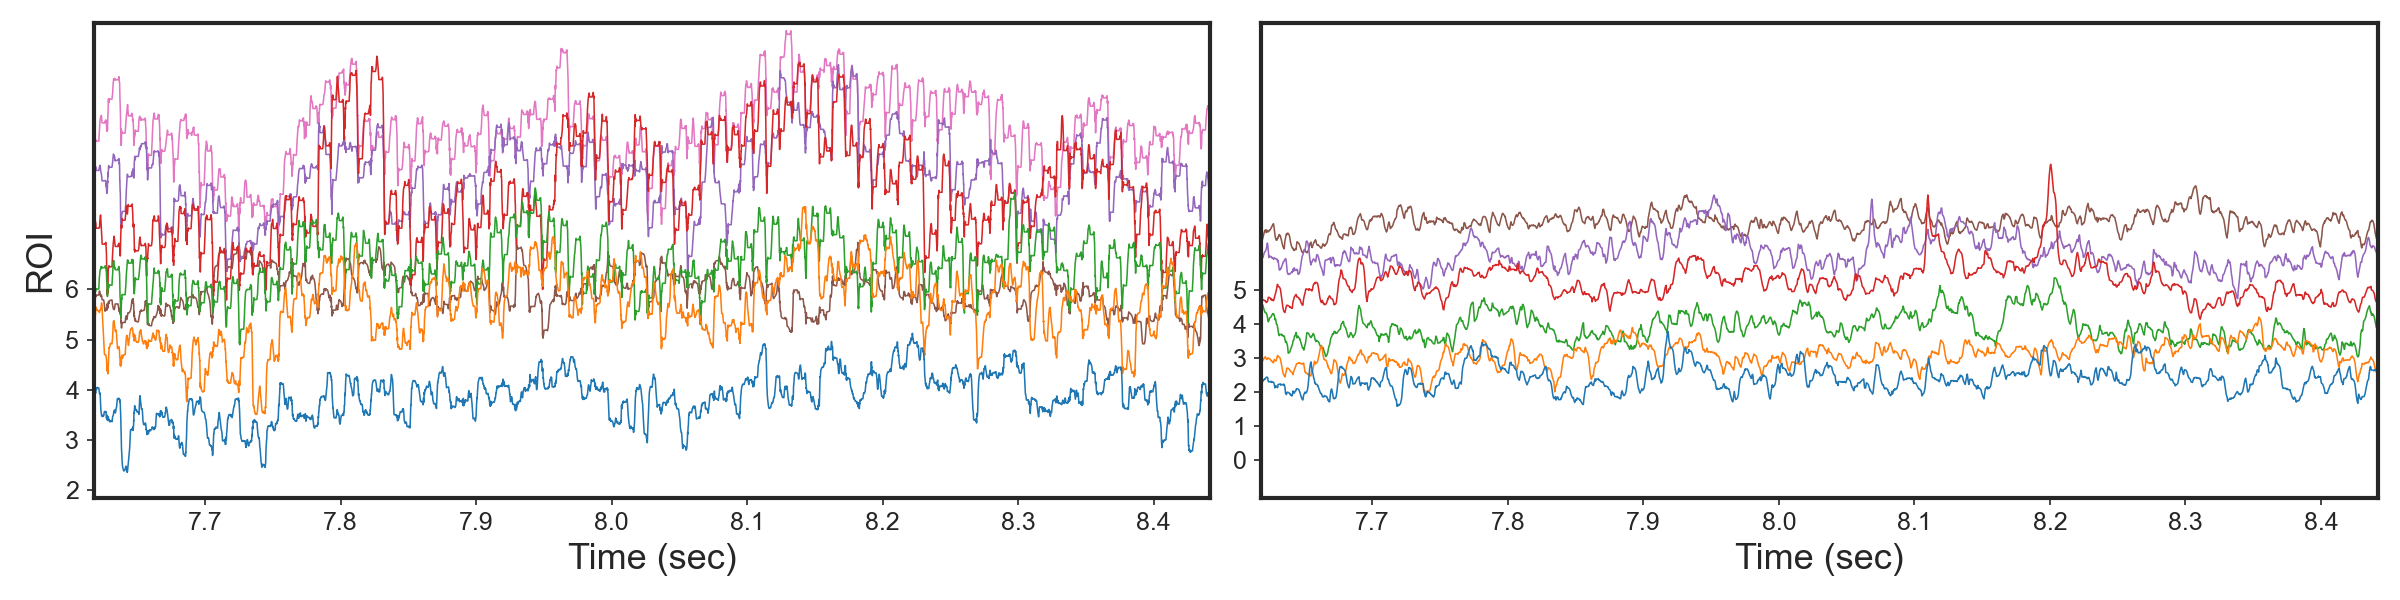

In [18]:
fig,ax=plt.subplots(1,2,figsize=(16,4),sharex = True, sharey=False)

for i,axis in enumerate(ax.flatten()):
    axis.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
    axis.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)
    axis.set_xlabel('Time (sec)')
    for spine in ['left','bottom','top','right']:
        axis.spines[spine].set_linewidth(2)
    
ax[0].set_ylabel('ROI')
    
offset = 5000
sample_rate = 10_800
for ii,dmd in enumerate([dmd1_traces,dmd2_traces]):
    yticks = []
    for iii,roi in enumerate(dmd):
        t = np.linspace(0,len(roi)/sample_rate,len(roi))
        ax[ii].plot(t,(roi-roi[0])+iii*offset,zorder=-iii,lw=0.75)
        ytick = iii*offset
        yticks.append(ytick)
    ax[ii].set_yticks(yticks)
    ax[ii].set_yticklabels(range(len(dmd)))
    
fig.tight_layout()
filen = '2026-06-23_ASAP8y_example'
# save_figure(fig,os.path.join(savepath,filen),formats = ['.pdf'],dpi=300)

<IPython.core.display.Javascript object>


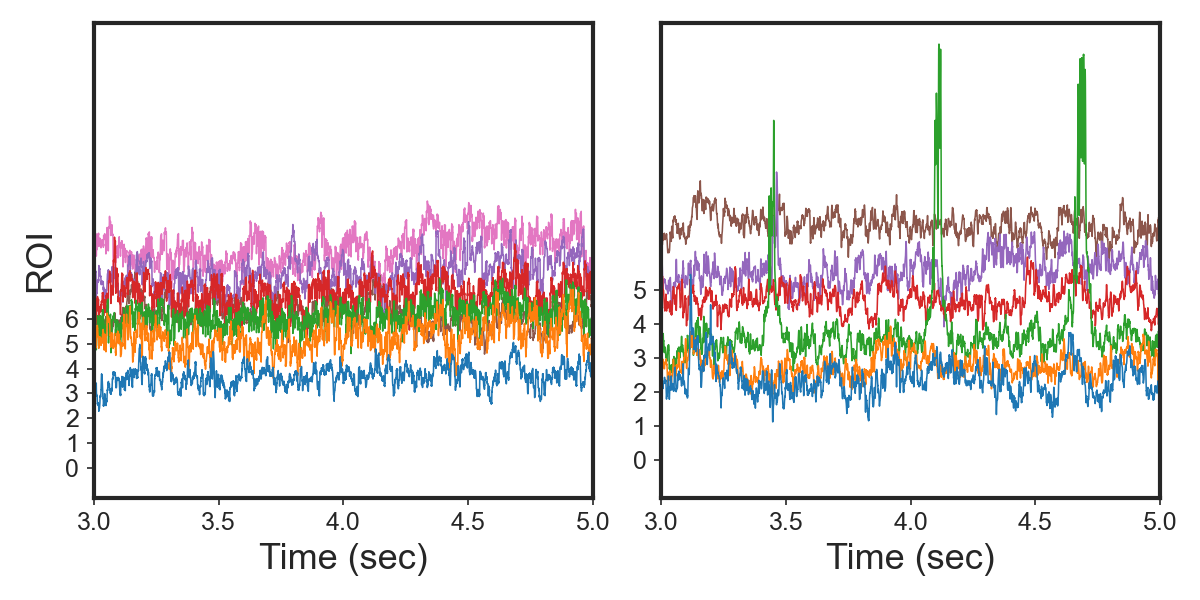

In [19]:
fig,ax=plt.subplots(1,2,figsize=(8,4),sharex = True, sharey=False)

for i,axis in enumerate(ax.flatten()):
    axis.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
    axis.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)
    axis.set_xlabel('Time (sec)')
    axis.set_xlim(3,5)
    for spine in ['left','bottom','top','right']:
        axis.spines[spine].set_linewidth(2)
    
ax[0].set_ylabel('ROI')
    
offset = 5000
sample_rate = 10_800
for ii,dmd in enumerate([dmd1_traces,dmd2_traces]):
    yticks = []
    for iii,roi in enumerate(dmd):
        t = np.linspace(0,len(roi)/sample_rate,len(roi))
        ax[ii].plot(t,(roi-roi[0])+iii*offset,zorder=-iii,lw=0.75)
        ytick = iii*offset
        yticks.append(ytick)
    ax[ii].set_yticks(yticks)
    ax[ii].set_yticklabels(range(len(dmd)))
    
fig.tight_layout()
filen = '2026-06-16_ASAP8y_example_inset2'
# save_figure(fig,os.path.join(savepath,filen),formats = ['.pdf'],dpi=300)

In [21]:
masks = vs.get_roi_masks(dmd=1).astype(int)

<IPython.core.display.Javascript object>


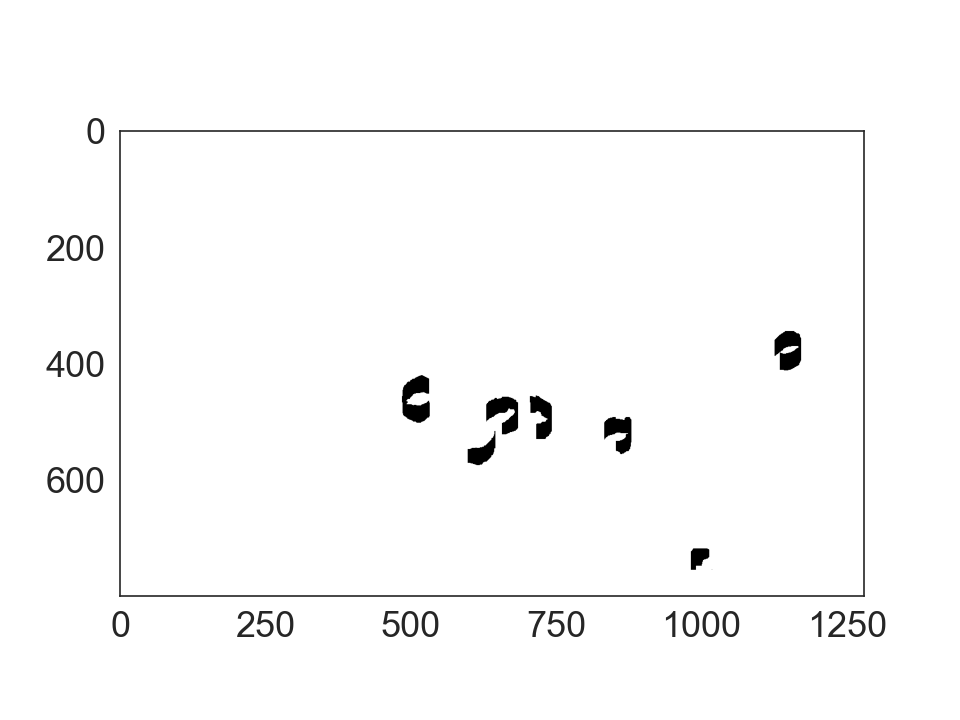

In [22]:
fig,ax=plt.subplots()
ax.imshow(masks[:,:,1],cmap='Greys_r')
ax.imshow(-np.sum(masks,axis=2),cmap='Greys_r')
filen = '2026-06-16_DMD2_masks'
# save_figure(fig,os.path.join(savepath,filen),formats = ['.pdf'],dpi=300)

### Per-ROI Spike-triggered averages